### Test the model as a binary classification task ###

In [1]:
import os
import sys
import pandas as pd
import numpy as np
import copy
import glob
import json
from dotenv import load_dotenv
from pathlib import Path
import albumentations as alb
from matplotlib import pyplot as plt
from matplotlib import colormaps

# PyTorch
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

# The Scikit-Learn pacage
from sklearn.metrics import roc_auc_score, roc_curve, precision_recall_curve, f1_score 
from sklearn.metrics import accuracy_score, confusion_matrix, auc

# Import this module with autoreload
%load_ext autoreload
%autoreload 2

import computervision as cv
from computervision.imageproc import is_image, ImageData
from computervision.inference import get_gpu_info
from computervision.datasets import DatasetFromDF
from computervision.models.lightningmodel import ToothModel

# Print version info
print(f'Package version: {cv.__version__}')
print(f'Authors:         {cv.__authors__}')
print(f'Python version:  {sys.version}')

Package version: 0.0.1
Authors:         The Core for Computational Biomedicine at Harvard Medical School
https://dbmi.hms.harvard.edu/about-dbmi/core-computational-biomedicine
Python version:  3.12.13 (main, Apr 16 2026, 08:53:58) [GCC 13.3.0]


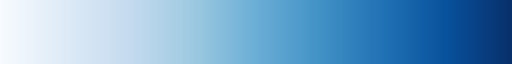

In [2]:
# Appearance of the output plots
plt.style.use('default')
SMALL_SIZE = 10
MEDIUM_SIZE = 12
BIGGER_SIZE = 14

plt.rc('font', size=SMALL_SIZE)          # controls default text sizes
plt.rc('axes', titlesize=SMALL_SIZE)     # fontsize of the axes title
plt.rc('axes', labelsize=MEDIUM_SIZE)    # fontsize of the x and y labels
plt.rc('xtick', labelsize=SMALL_SIZE)    # fontsize of the tick labels
plt.rc('ytick', labelsize=SMALL_SIZE)    # fontsize of the tick labels
plt.rc('legend', fontsize=SMALL_SIZE)    # legend fontsize
plt.rc('figure', titlesize=BIGGER_SIZE)  # fontsize of the figure title

# Color map
cmap = colormaps.get('Blues')
display(cmap)
# Generate a list of colors
n_colors = 10
colors = cmap(np.linspace(0.5, 1, n_colors))

In [3]:
print(plt.style.available)

['Solarize_Light2', 'bmh', 'classic', 'dark_background', 'fast', 'fivethirtyeight', 'ggplot', 'grayscale', 'petroff10', 'petroff6', 'petroff8', 'seaborn-v0_8', 'seaborn-v0_8-bright', 'seaborn-v0_8-colorblind', 'seaborn-v0_8-dark', 'seaborn-v0_8-dark-palette', 'seaborn-v0_8-darkgrid', 'seaborn-v0_8-deep', 'seaborn-v0_8-muted', 'seaborn-v0_8-notebook', 'seaborn-v0_8-paper', 'seaborn-v0_8-pastel', 'seaborn-v0_8-poster', 'seaborn-v0_8-talk', 'seaborn-v0_8-ticks', 'seaborn-v0_8-white', 'seaborn-v0_8-whitegrid', 'tableau-colorblind10']


In [4]:
# Load environmental variables
load_dotenv()
data_root = os.environ.get('DATA_DIR')
if data_root is None:
    print('Edit the "env"file and copy it to the root of the repository.') 
    raise FileNotFoundError('No .env file found. The data directory was not set.')

# Directory to store the data
dataset_name = 'classification'
data_dir = os.path.join(data_root, dataset_name)
example_dir = os.path.join(data_dir, 'examples')

# URL with the data set for manual download
url = os.environ.get('CL_URL')
image_dir_name = os.path.basename(url).split('.')[0]
image_dir = os.path.join(data_dir, image_dir_name, 'cropped')

# Verify the image data on disk
file_list = glob.glob(os.path.join(image_dir, '*.jpg'))
print(len(file_list))

# Set up a model directory for the trained model
model_dir = os.path.join(data_dir, 'model', 'lightningmodel')
Path(model_dir).mkdir(exist_ok=True, parents=True)

device, device_str = get_gpu_info()

7697
CUDA available: True
Number of GPUs found:  1
Current device ID: 0
GPU device name:   NVIDIA GeForce RTX 3060 Laptop GPU
PyTorch version:   2.13.0+cu130
CUDA version:      13.0
CUDNN version:     92000
Current device:    cuda:0


### Helper functions ###

In [5]:
def find_closest_index(array, target_value):
    """
    Finds the index of the value in a NumPy array closest to the target value.
    """
    # Calculate the absolute difference between each element and the target value
    absolute_differences = np.abs(array - target_value)
    # Find the index of the minimum difference
    closest_index = absolute_differences.argmin()
    return closest_index

### Load the test data ###

In [6]:
annotations_file_name = 'annotations_cropped_dset.parquet'
annotations_file = os.path.join(image_dir, annotations_file_name)
df = pd.read_parquet(annotations_file)

file_col = 'file_name'
bbox_col= 'bbox'
label_col = 'label'
dset_col = 'dset'
pred_col = 'pred'
score_col = 'score'
pos_col = 'pos'

# Check the images
file_list = [os.path.join(image_dir, file_name) for file_name in df[file_col].unique()]
checked = [is_image(file) for file in file_list]
assert len(file_list) == sum(checked), f'WARNING: Could not open all {len(file_list)} images at: {image_dir}'
print(f'Image directory:        {image_dir}')
print(f'Total number of images: {len(file_list)}')
print(f'Annotations:            {df.shape[0]}')
display(df.head(2))

Image directory:        /home/andreas/data/cv_data/classification/dataset_dental_roboflow/cropped
Total number of images: 7550
Annotations:            7550


,multi_file,file_name,width,height,area,label,bbox,pos,pos_bbox,dset
0,a0ab0bec5c.jpg,tooth_02_a0ab0bec5c.jpg,152,236,35872,tooth,None,[2],None,train
1,5c6869fdf0.jpg,amalgam_03_5c6869fdf0.jpg,427,265,113155,amalgam,"[182, 29, 119, 112]","[19, 20]","[[143, 20, 284, 245], [20, 33, 382, 232]]",train


### Run the predictions on the test data ###

In [7]:
model_name = 'lightningmodel'
model_number = 2
model_number_str = str(model_number).zfill(2)
model_dir_name = f'{model_name}_{model_number_str}'
checkpoint_dir = os.path.join(model_dir, model_dir_name)

# Find the checkpoint files
print(checkpoint_dir)
checkpoint_files = sorted(list(glob.glob(os.path.join(checkpoint_dir, '*.ckpt'))))
checkpoint_names = [os.path.basename(file) for file in checkpoint_files]
checkpoint_dict = dict(zip(checkpoint_names, checkpoint_files))
print(f'Checkpoints found: {checkpoint_names}')

# Load model configuration
json_file = os.path.join(checkpoint_dir, f'{model_name}.json')
with open(json_file, 'r') as f:
    parameters = json.load(f)

# We need to add the correct categories to the test data
id2label = parameters.get('id2label')
label2id = {label: int(id) for id, label in id2label.items()}

# Make sure we have the correct category label for the data
df = df.assign(category=df[label_col].apply(lambda label: label2id.get(label)))
display(df.head())
label_dict = {int(category): label for category, label in id2label.items()}
display(label_dict)

/home/andreas/data/cv_data/classification/model/lightningmodel/lightningmodel_02
Checkpoints found: []


FileNotFoundError: [Errno 2] No such file or directory: '/home/andreas/data/cv_data/classification/model/lightningmodel/lightningmodel_02/lightningmodel.json'

### Test data set ###

In [ ]:
# Get the test data
# test_df = df.loc[df['dset'].isin(['val', 'test'])]
test_df = df.loc[df['dset'] == 'test']

# Initial scaling and padding for the bigger dimension
model_info = parameters.get('model_info')
max_image_size = model_info.get('max_image_size')

# Model input size
im_width = model_info.get('im_width')
im_height = model_info.get('im_height')

# Resize and then normalize 
# with ImageNet mean and standard deviation for ResNet50
image_net_mean = ImageData().image_net_mean
image_net_std = ImageData().image_net_std

# This transform is essential and needs to be applied for both training and validation
resize_and_normalize = [alb.Resize(width=im_width, height=im_height),
                        alb.Normalize(mean=image_net_mean, std=image_net_std)]

# However, for validation and testing, we don't want the augmentations, 
# so we just resize and normalize the data
test_transform = alb.Compose(resize_and_normalize)

In [ ]:
test_dataset = DatasetFromDF(data=test_df,
                             image_dir=image_dir,
                             file_name_col=file_col,
                             label_id_col='category',
                             max_image_size=max_image_size,
                             transform=test_transform,
                             validate=True)

print(len(test_dataset))

# Create a data loader
batch_size = 6
dl = DataLoader(test_dataset,
                batch_size=batch_size,
                num_workers=0,
                shuffle=False)

### Load the model from a checkpoint ###

In [ ]:
print(checkpoint_names)
num_classes = len(id2label)
chk = 0 
checkpoint_name = checkpoint_names[chk]
# for chk, checkpoint_name in enumerate(checkpoint_names):
checkpoint_file = checkpoint_dict.get(checkpoint_name)
print(f'Checkpoint:      {checkpoint_name}')
print(f'Checkpoint file: {checkpoint_file}')

model = ToothModel.load_from_checkpoint(checkpoint_file,
                                        weights_only=False,
                                        test_dataset=test_dataset, 
                                        map_location=device,
                                        batch_size=batch_size,
                                        num_classes=num_classes,
                                        num_workers=1)
sm = nn.Softmax(dim=1)

In [ ]:
pred_df_batch_list = []
for image_batch, label_batch in dl:
    pred_df_batch = pd.DataFrame(sm(model(image_batch.to(device))).cpu().detach().numpy()).\
        assign(cl=list(label_batch.detach().numpy()))
    pred_df_batch_list.append(pred_df_batch)

pred_df = pd.concat(pred_df_batch_list, axis=0, ignore_index=True).\
    assign(checkpoint=checkpoint_name,
           model_name=model_name,
           model_number=model_number)

display(pred_df.sample(10))

In [ ]:
# Save the predictions
predictions_file = os.path.join(checkpoint_dir, 'test_predictions.parquet')
pred_df_save = copy.deepcopy(pred_df)
pred_df_save.columns = pred_df_save.columns.astype(str)
pred_df_save.to_parquet(predictions_file)

### Performance metrics for binary classification task ###

In [ ]:
print(example_dir)

In [ ]:
# We will pick two classes in the test data
print(label2id)
for positive in ['tooth', 'amalgam', 'composite', 'root filling', 'Calculus', 'caries']:
    # positive = 'amalgam'
    negative = 'tooth'
    cl_list = [label2id.get(positive), label2id.get(negative)]
    print(dict(zip(['positive', 'negative'], cl_list)))
    
    # Set the positive class to 1, negative 0:
    y_true = [1 if c == label2id.get(positive) else 0 for c in pred_df['cl'].values]
    y_score = pred_df[label2id.get(positive)]
    
    # Get the threshold to achieve a 70% recall
    recall_value = 0.7
    precision, recall, p_thresholds = precision_recall_curve(y_true=y_true, y_score=y_score)
    auc_pr = auc(x=recall, y=precision)
    p_idx = int(find_closest_index(array=recall, target_value=recall_value))
    p_thr = p_thresholds[p_idx]
    print()
    print(positive.upper())
    print()
    print('P-R')
    print(f'P-R: Index for recall threshold: {p_idx}')
    print(f'P-R: Recall value at index:      {recall[p_idx]:.3f}')
    print(f'P-R: Threshold:                  {p_thr:.3f}')
    print(f'P-R: AUC:                        {auc_pr:.3f}')
    
    fpr, tpr, r_thresholds = roc_curve(y_true=y_true, y_score=y_score)
    auc_roc = auc(x=fpr, y=tpr)
    auc_roc_2 = roc_auc_score(y_true=y_true, y_score=y_score)
    r_idx = int(find_closest_index(array=r_thresholds, target_value=p_thr))
    r_thr = r_thresholds[r_idx]
    print()
    print('ROC')
    print(f'ROC: Index:     {r_idx}')
    print(f'ROC: Threshold: {r_thr:.3f}')
    print(f'ROC: TPR:       {tpr[r_idx]:.3f}')
    print(f'ROC: FPR:       {fpr[r_idx]:.3f}')
    print(f'ROC: AUC:       {auc_roc:.3f}')
    print(f'ROC: AUC:       {auc_roc_2:.3f}')
    
    # For this threshold, calculate the confusion matrix
    y_pred = [1 if score >= r_thr else 0 for score in y_score]
    tn, fp, fn, tp = confusion_matrix(y_true=y_true, y_pred=y_pred).ravel().tolist()
    f1 = f1_score(y_true=y_true, y_pred=y_pred)
    
    print()
    print(f'Confusion matrix for threshold: {r_thr:.3f}')
    print(f'TP: {tp} FN: {fn}')
    print(f'FP: {fp} TN: {tn}')
    print()
    print(f'Actual positives P = TP + FN = {tp + fn}')
    print(f'Actual negatives N = FP + TN = {fp + tn}')
    print()
    print(f'Predicted positives PP = TP + FP  = {tp + fp}')
    print(f'Predicted negatives PN = FN + TN  = {fn + tn}')
    print()
    rec = tp / (tp + fn)
    pre = tp / (tp + fp)
    print(f'Recall = TP / (TP + FN) = TP / P  = {rec:.3f}')
    print(f'Precision = TP / (TP + FP) = TP / PP = {pre:.3f}')
    print(f'Accuracy = TP + TN / P + N = {(tp + tn) / (tp + fn + fp + tn):.3f}')
    print(f'Specificity = TN / N = {tn / (fp + tn)}')
    print(f'F1 = 2 x precision * recall / (precision + recall) = {2 * pre * rec / (pre + rec):.3f}')
    print(f'F1 =                                                 {f1:.3f}') 
    
    # The minimum precision is calculated for a classifier that predicts only positive results
    minimum_precision = (tp + fn) / (tp + fn + fp + tn)
    print(f'Minimum precision (baseline rate of the positive class) P / (P + N): {minimum_precision:.3f}')

    print()
    # ROC curve
    figsize = (6, 6)
    # color='royalblue'
    color = colors[4]
    fig, ax = plt.subplots(figsize=figsize)
    ax.plot(fpr, tpr, color=color, linewidth=2.0, alpha=1.0)
    ax.text(x=0.75, y=0, s=f'auc={auc_roc:.3f}', alpha=1.0, color=color)
    ax.set(xlim=[-0.05, 1.05], ylim=[-0.05, 1.05], 
           xticks=np.arange(0, 1.2, 0.2), yticks=np.arange(0, 1.2, 0.2),
           xlabel='False positive rate', ylabel='True positive rate')
    ax.plot([0.05, 0.95], [0.05, 0.95], transform=ax.transAxes, color='k', linewidth=2, alpha=0.8, linestyle=':')
    
    # Mark the threshold that we used for the stats
    ax.scatter(float(fpr[r_idx]), float(tpr[r_idx]), color='r', s=25)
    ax.set(title=positive.title())
    ax.grid(True)
    
    # Create an image name
    image_name = f'ROC_{positive.upper()}_test.png'
    image_file = os.path.join(example_dir, image_name)
    plt.savefig(image_file, bbox_inches='tight')
    plt.show()
    
    # P-R Curve
    fig, ax = plt.subplots(figsize=figsize)
    ax.plot(recall, precision, color=color, linewidth=2.0, alpha=1.0)
    ax.text(x=0.75, y=0, s=f'auc={auc_pr:.3f}', alpha=1.0, color=color)
    ax.set(xlim=[-0.05, 1.05], ylim=[-0.05, 1.05],
           xticks=np.arange(0, 1.2, 0.2), yticks=np.arange(0, 1.2, 0.2),
           xlabel='Recall', ylabel='Precision')
    ax.plot([0.05, 0.95], [minimum_precision, minimum_precision], 
            transform=ax.transAxes, color='k', linewidth=2, alpha=0.8, linestyle=':')
    
    # Mark the threshold that we used for the stats
    ax.scatter(float(recall[p_idx]), float(precision[p_idx]), color='r', s=25)
    ax.set(title=positive.title())
    ax.grid(True)
    
    image_name = f'PR_{positive.upper()}_test.png'
    image_file = os.path.join(example_dir, image_name)
    plt.savefig(image_file, bbox_inches='tight')
    plt.show()

In [ ]:
# ROC curve
figsize = (4, 4)
color='royalblue'
fig, ax = plt.subplots(figsize=figsize)
ax.plot(fpr, tpr, color=color, linewidth=2.0, alpha=1.0)
ax.text(x=0.75, y=0, s=f'auc={auc_roc:.3f}', alpha=1.0, color=color)
ax.set(xlim=[-0.05, 1.05], ylim=[-0.05, 1.05], 
       xticks=np.arange(0, 1.2, 0.2), yticks=np.arange(0, 1.2, 0.2),
       xlabel='False positive rate', ylabel='True positive rate')
ax.plot([0.05, 0.95], [0.05, 0.95], transform=ax.transAxes, color='k', linewidth=2, alpha=0.8, linestyle=':')

# Mark the threshold that we used for the stats
ax.scatter(float(fpr[r_idx]), float(tpr[r_idx]), color='r', s=25)
ax.set(title=positive.title())

# Create an image name
image_name = f'ROC_{positive.upper()}_test.png'
image_file = os.path.join(example_dir, image_name)
plt.savefig(image_file, bbox_inches='tight')
plt.show()

In [ ]:
# P-R Curve
fig, ax = plt.subplots(figsize=figsize)
ax.plot(recall, precision, color=color, linewidth=2.0, alpha=1.0)
ax.text(x=0.75, y=0, s=f'auc={auc_pr:.3f}', alpha=1.0, color=color)
ax.set(xlim=[-0.05, 1.05], ylim=[-0.05, 1.05],
       xticks=np.arange(0, 1.2, 0.2), yticks=np.arange(0, 1.2, 0.2),
       xlabel='Recall', ylabel='Precision')
ax.plot([0.05, 0.95], [minimum_precision, minimum_precision], 
        transform=ax.transAxes, color='k', linewidth=2, alpha=0.8, linestyle=':')

# Mark the threshold that we used for the stats
ax.scatter(float(recall[p_idx]), float(precision[p_idx]), color='r', s=25)
ax.set(title=positive.title())

image_name = f'PR_{positive.upper()}_test.png'
image_file = os.path.join(example_dir, image_name)
plt.savefig(image_file, bbox_inches='tight')
plt.show()